### 画像マーカープロットを使った効果的なデータ可視化
参考サイト：https://sabopy.com/py/matplotlib-picplot/  
（事前準備）マーカーとして使う画像ファイル（この例では`sweets_montblanc.png`）を、ipynb と同じフォルダに入れておく。

In [1]:
# 数値演算、描画用ライブラリ読み込み
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# グラフをinline表示可能にする
%matplotlib inline

# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

# 日本語表示用ライブラリ（matplotlibで日本語を使用したい場合）
try:
  import japanize_matplotlib
except ModuleNotFoundError:
  # 初回だけインストールするので時間がかかる
  !pip install japanize-matplotlib
  import japanize_matplotlib

In [2]:
# このハコ部分は、この授業の範囲内では、こういうもんか、で構いません。そのまま使ってください。
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def imscatter(x, y, image_path, ax=None, zoom=1):
    """
    画像をマーカーとしてプロットする関数
    
    Parameters
    ----------
    x, y : array_like
        プロット座標
    image_path : str
        画像ファイルのパス
    ax : matplotlib.axes.Axes, optional
        プロット先の軸
    zoom : float, optional
        画像の拡大率
        
    Returns
    -------
    artists : list
        プロットした画像のリスト
    """
        
    # 画像の読み込み
    try:
        image = plt.imread(image_path)
    except FileNotFoundError:
        print(f"画像ファイル '{image_path}' が見つかりません。")
        return []
        
    # OffsetImageオブジェクトの作成
    im = OffsetImage(image, zoom=zoom)
    
    # 入力座標の確認（1次元以上のarrayに変換）
    x, y = np.atleast_1d(x, y)
    
    # 各点に画像をプロット
    artists = []
    for x0, y0 in zip(x, y):
        ab = AnnotationBbox(im, (x0, y0), xycoords='data', frameon=False)
        artists.append(ax.add_artist(ab))
    
    # 軸の調整
    ax.update_datalim(np.column_stack([x, y]))
    ax.autoscale()
    return artists


def imscatter_sized(x, y, z, image_path, ax=None, zoom_factor=0.2):
    """zの値に応じて画像サイズを変更するプロット関数"""
    
    image = plt.imread(image_path)
    
    # 正規化してサイズを調整
    z_norm = (z - np.min(z)) / (np.max(z) - np.min(z)) * 0.8 + 0.2
    
    artists = []
    for x0, y0, z0 in zip(x, y, z_norm):
        # z値に基づいてズームレベルを変更
        im = OffsetImage(image, zoom=z0 * zoom_factor)
        ab = AnnotationBbox(im, (x0, y0), xycoords='data', frameon=False)
        artists.append(ax.add_artist(ab))
    
    ax.update_datalim(np.column_stack([x, y]))
    ax.autoscale()
    return artists

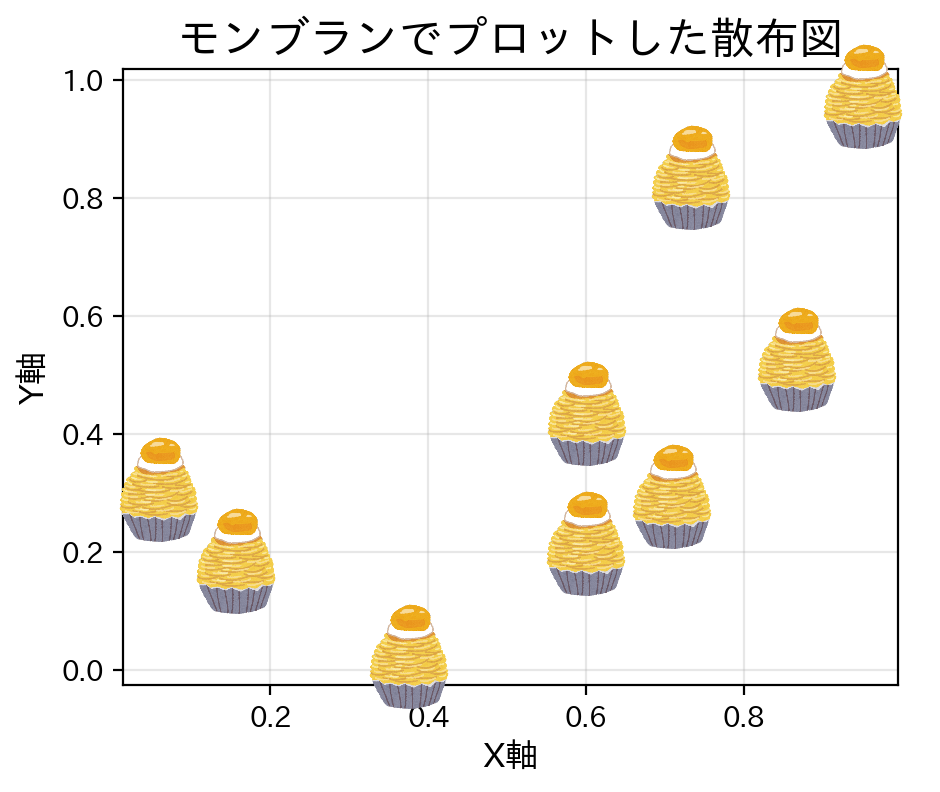

In [3]:
# グラフサイズの指定
plt.figure(figsize=(5, 4))

x=[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864, 0.15599452, 
   0.05808361, 0.86617615, 0.60111501, 0.70807258]
y=[0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497, 0.18340451, 
   0.30424224, 0.52475643, 0.43194502, 0.29122914]

# プロットに用いる画像のファイル名指定
image_path = "sweets_montblanc.png"

# 指定した画像をマーカーとして描画するための関数（上で定義したもの）呼び出し
imscatter(x, y, image_path, ax=plt.gca(), zoom=0.1)

# 参考のため点も表示（透明度 alpha=0で非表示）
plt.plot(x, y, 'ko', alpha=0)

# グラフの見た目を調整
plt.title('モンブランでプロットした散布図', fontsize=16)
plt.xlabel('X軸', fontsize=12)
plt.ylabel('Y軸', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

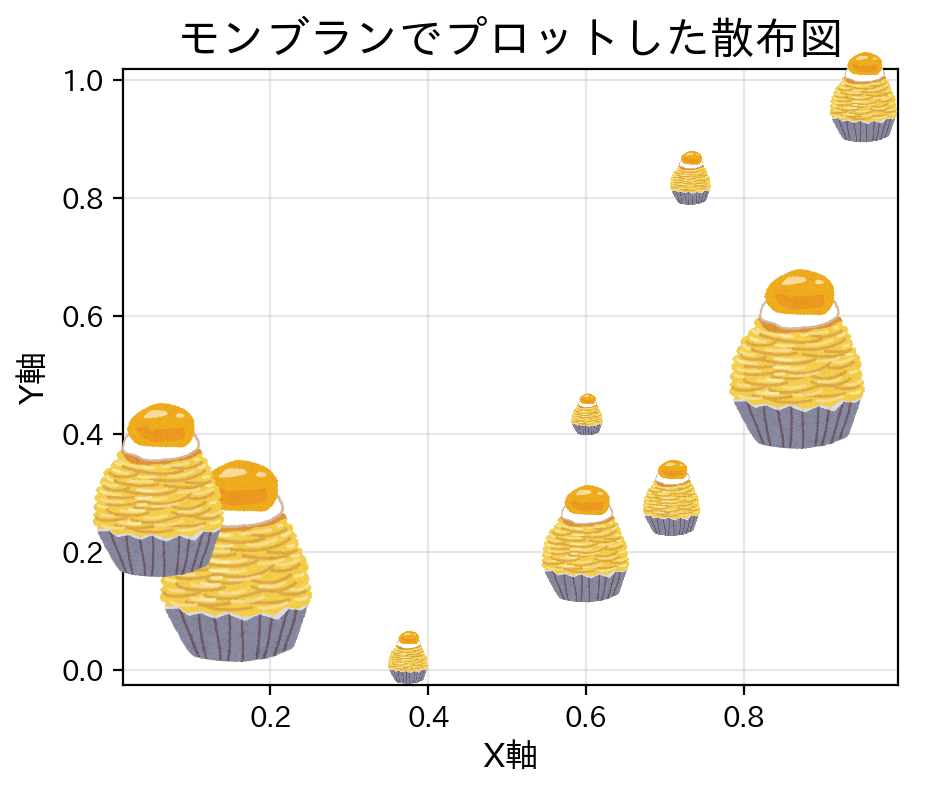

In [9]:
# グラフサイズの指定
plt.figure(figsize=(5, 4))

# データ
x=[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864, 0.15599452, 
   0.05808361, 0.86617615, 0.60111501, 0.70807258]
y=[0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497, 0.18340451, 
   0.30424224, 0.52475643, 0.43194502, 0.29122914]

# サイズ用リスト
z = [1.0204565, 3.08300821, 1.07820208, 4.5827623, 1.81903223, 9.30963818,
     7.78341849,8.0604126, 0.39115229, 2.31873152, 2.21478582, 5.42000623,
     3.43842051, 0.89046952, 9.61369357]

# プロットに用いる画像のファイル名指定
image_path = "sweets_montblanc.png"

# 指定した画像をマーカーとして描画するための関数（上で定義したもの）呼び出し
imscatter_sized(x, y, z, "sweets_montblanc.png", ax=plt.gca())

# 参考のため点も表示（透明度 alpha=0で非表示）
plt.plot(x, y, 'ko', alpha=0)

# グラフの見た目を調整
plt.title('モンブランでプロットした散布図', fontsize=16)
plt.xlabel('X軸', fontsize=12)
plt.ylabel('Y軸', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('cactus_plot.png', dpi=100, bbox_inches='tight', transparent=True)
plt.show()

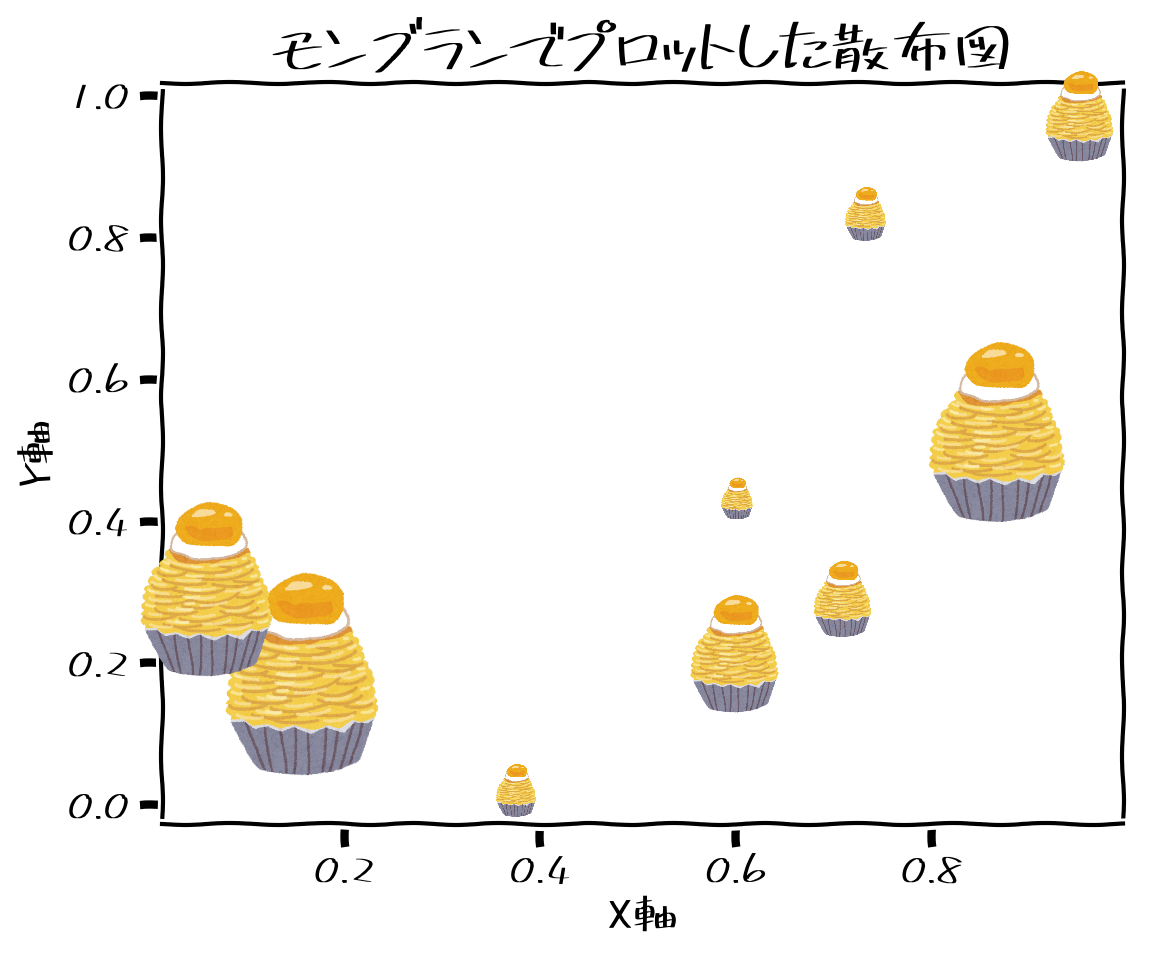

In [7]:
with plt.xkcd():
    #   脱力系日本語フォント指定
    #plt.rcParams["font.family"] = "Natsume"
    plt.rcParams["font.family"] = "851MkPOP"
    #plt.rcParams["font.family"] = "851tegakizatsu"
    
    # グラフサイズの指定
    plt.figure(figsize=(6, 5))

    # データ
    x=[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864, 0.15599452, 
       0.05808361, 0.86617615, 0.60111501, 0.70807258]
    y=[0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497, 0.18340451, 
       0.30424224, 0.52475643, 0.43194502, 0.29122914]
    
    # サイズ用リスト
    z = [1.0204565, 3.08300821, 1.07820208, 4.5827623, 1.81903223, 9.30963818,
         7.78341849,8.0604126, 0.39115229, 2.31873152, 2.21478582, 5.42000623,
         3.43842051, 0.89046952, 9.61369357]
    
    # プロットに用いる画像のファイル名指定
    image_path = "sweets_montblanc.png"

    # 指定した画像をマーカーとして描画するための関数（上で定義したもの）呼び出し
    imscatter_sized(x, y, z, "sweets_montblanc.png", ax=plt.gca())
    
    # 参考のため点も表示（透明度 alpha=0で非表示）
    plt.plot(x, y, 'ko', alpha=0)
    
    # グラフの見た目を調整
    plt.title('モンブランでプロットした散布図', fontsize=22)
    plt.xlabel('X軸', fontsize=16)
    plt.ylabel('Y軸', fontsize=16)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cactus_plot.eps', dpi=100, bbox_inches='tight', transparent=True)
    plt.show()